# Expanding supernova sources

This source has no driving signal. Its luminosity, radius, and temperature already describe its intrinsic evolution. Leave `apply_driving_signal` unset in `system.light_curve`. Setting it to `False` also preserves the supernova evolution, while `True` raises an error because no driver is configured. If additional multiplicative modulation is intentional, use an explicit `ModulatedSource` wrapper.

Source evolution can be evaluated daily while dynamic microlensing maps use a different cadence. The built-in Type-Ia-like preset is a reproducibility example. Users may replace its evolution, spatial profile, or spectrum.

## Source morphology and unlensed evolution
The top-row profiles are the same photosphere at the observer-frame i-band peak. Their field covers the largest photosphere in the requested time interval with a 5% margin, so the peak need not fill the image. The light curves below are intrinsic band-integrated fluxes. The expansion, bolometric evolution, cooling, limb darkening, and approximate UV blanketing together produce wavelength-dependent peaks. These are source products. Microlensing is added by passing the source to a map-to-flux workflow.
The system supplies the redshift and luminosity distance. The 180-day source horizon keeps its field fixed for shorter requests. Increase that horizon before requesting a longer evolution. Position angles use degrees, as they do for disk sources.


In [1]:
from pathlib import Path
import numpy as np
from scipy.ndimage import gaussian_filter
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp
plt.rcParams.update(mcp.publication_style())
OUTPUT_DIRECTORY = Path('expanding_supernova_output')
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
evolution = mc.PowerLawExponentialPhotosphere(
    peak_time_rest_days=18.0, peak_luminosity_watts=10.0**36.2, rise_power=2.4,
    decline_time_rest_days=28.0, photosphere_velocity_km_s=12_000.0,
    initial_radius_m=1.0e9, temperature_floor_k=3_000.0, temperature_ceiling_k=18_000.0,
)
appearance = mc.PhotosphereAppearance(
    axis_ratio=0.9, position_angle_deg=25.0,
    limb_darkening=0.5, achromatic_phase_rest_days=21.0,
    chromatic_transition_rest_days=7.0, chromatic_limb_slope=0.15,
    uv_blanketing_wavelength_angstrom=4_000.0, uv_blanketing_tau_early=0.35,
    uv_blanketing_tau_late=1.0,
)
source_model = mc.ExpandingPhotosphereSource(
    bands_angstrom={'g': 4827.0, 'r': 6223.0, 'i': 7546.0},
    maximum_observer_time_days=180.0, source_margin=1.05,
    evolution=evolution, appearance=appearance, source_grid_shape=256,
)
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available and capabilities.triton_importable
runtime_config = mc.RuntimeConfig(
    device='cuda' if use_cuda else 'cpu',
    backend='triton' if use_cuda else 'auto',
    dtype=torch.float32, strict_backend=use_cuda,
)
population = mc.StellarPopulation.salpeter(
    mean_mass_solar=0.3,
    mass_ratio=100.0,
    kinematics=mc.SkyProjectedKinematics(
        ra_deg=172.964, dec_deg=-12.533,
        stellar_dispersion_km_s=170.0,
        peculiar_velocity_dispersion_km_s=235.0,
        include_cmb_dipole=True, seed=0,
    ),
)
system = mc.MicrolensingSystem(
    lens_redshift=0.30,
    source_redshift=0.65,
    H0=70.0,
    Om0=0.3,
    macro=mc.MacroLens(convergence=0.35, shear=0.20),
    stellar_population=population,
    source=source_model,
    duration_days=180.0,
    light_loss=0.01,
    safety_scale=1.5,
    seed=0,
    runtime=runtime_config,
)
source = system.realize().source
times = torch.arange(0.0, 181.0)
curve = mc.source_light_curve(source, times, batch_size=16)
flux = curve.flux
peak_index = int(torch.argmax(flux[:, source.geometry.band_names.index('i')]))
print('i-band peak:', float(times[peak_index]), 'observer days')

i-band peak: 30.0 observer days


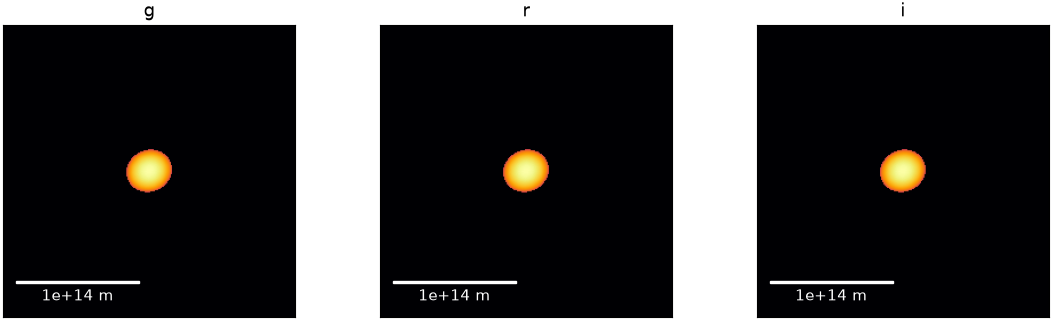

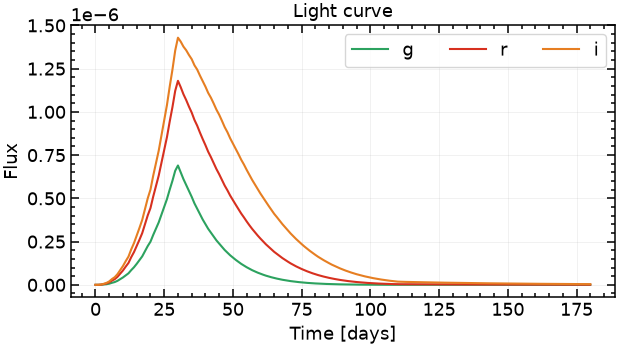

In [2]:
figure, axes = plt.subplots(1, 3, figsize=(11.5, 3.5))
for ax, band in zip(axes, source.geometry.band_names, strict=True):
    mcp.plot_source_brightness(
        source,
        time_days=float(times[peak_index]),
        band=band,
        ax=ax,
        colorbar=False,
        scale_bar_m=1.0e14,
        show_axes=False,
        title=band,
    )
figure.tight_layout()
figure, ax = mcp.plot_light_curve(curve, magnitude=False)
figure.tight_layout()

## A microlensed supernova light curve

The source evolves daily while the magnification map is updated every ten days. The CUDA calculation uses the same validated dynamic tiled-IPM settings as the quasar examples. Only the source grid is reduced to $256^2$, which is appropriate for this smooth expanding photosphere.

Map epochs: 19 daily source epochs: 181


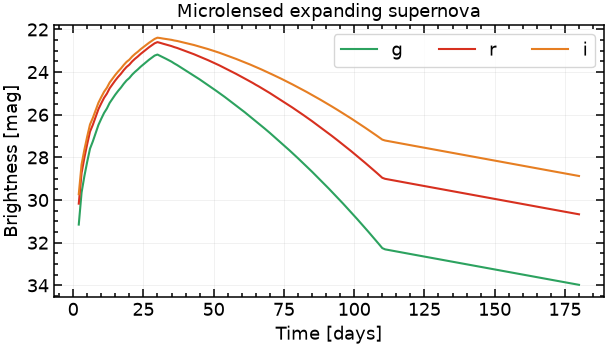

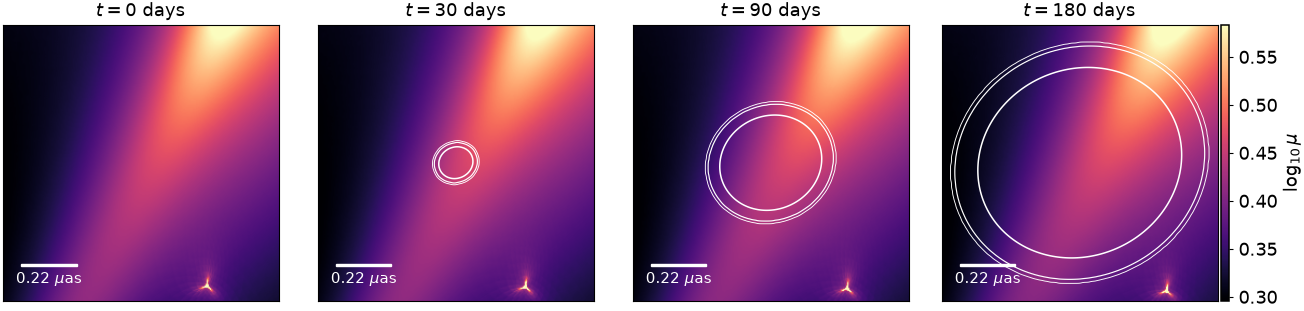

In [3]:
source_grid = system.resolved_source_grid
source_width_uas = source_grid.field_of_view_uas[1]
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
    cell_chunk_size=524_288 if use_cuda else 65_536,
)
map_times = torch.arange(0.0, 180.0 + 5.0, 10.0)
flux_times = torch.arange(0.0, 180.0 + 0.5, 1.0)
display_map_indices = sorted(set((0, int(round(peak_index / 10.0)), len(map_times) // 2, len(map_times) - 1)))
display_map_times = tuple(float(map_times[index]) for index in display_map_indices)
lensed_curve = system.light_curve(
    duration_days=180, map_cadence_days=10, source_cadence_days=1,
    method=method, temporal_batch_size=49, scout_refresh_frames=10,
    keep_maps_at_days=display_map_times,
)
figure, ax = mcp.plot_light_curve(
    lensed_curve, magnitude=True, normalize=False,
    title='Microlensed expanding supernova',
)
ax.set_ylabel('Brightness [mag]')
figure.tight_layout()
print('Map epochs:', len(map_times), 'daily source epochs:', len(flux_times))

# Show the expanding i-band photosphere directly on contemporaneous dynamic
# point-source magnification maps.  Contour smoothing is display-only.
maps_for_display = [
    torch.log10(magnification_map.values.cpu().clamp_min(1.0e-2)).numpy()
    for magnification_map in lensed_curve.maps
]
map_vmin, map_vmax = np.quantile(np.stack(maps_for_display), (0.005, 0.995))
x0, x1, y0, y1 = source_grid.bounds_uas
source_x = np.linspace(x0, x1, source.geometry.shape[1])
source_y = np.linspace(y0, y1, source.geometry.shape[0])
figure, axes = plt.subplots(1, len(display_map_indices), figsize=(3.35 * len(display_map_indices), 3.25))
for ax, map_index, log_map in zip(axes, display_map_indices, maps_for_display, strict=True):
    artist = ax.imshow(
        log_map, origin='lower', extent=source_grid.bounds_uas, cmap='magma',
        vmin=map_vmin, vmax=map_vmax, interpolation='bilinear',
    )
    epoch = float(map_times[map_index])
    profile = source.brightness(epoch)[0, :, :, source.geometry.band_names.index('i')].detach().cpu().numpy()
    profile = gaussian_filter(profile, sigma=1.5, mode='nearest')
    positive = profile[profile > 0.0]
    if positive.size:
        levels = mcp.enclosed_flux_contour_levels(
            profile, fractions=(0.68, 0.95, 0.99),
        )
        ax.contour(
            source_x, source_y, profile, levels=levels, colors='white',
            linewidths=(0.65, 0.85, 1.1),
        )
    ax.set_title(fr'$t={epoch:.0f}$ days')
    mcp.add_scale_bar(ax, 0.2 * source_width_uas, label=fr'{0.2 * source_width_uas:.2g} $\mu$as', color='white')
    mcp.hide_image_axes(ax, keep_frame=True)
mcp.panel_colorbar(figure, axes[-1], artist, label=r'$\log_{10}\mu$', size='3%', pad=0.035)
figure.tight_layout()
figure.savefig(OUTPUT_DIRECTORY / 'expanding_photosphere_over_dynamic_maps.png', dpi=220, bbox_inches='tight', facecolor='white')
